In [1]:
# Parse timing output files to extract wall time.
import os, re, glob, pandas as pd

def parse_folder(folder, file_glob='*.time'):
    files = sorted(glob.glob(os.path.join(folder, file_glob)))

    wall_time_rows = []

    real_re = re.compile(r'^real\s+(\d+)m([0-9.]+)s')
    elapsed_re = re.compile(r'Elapsed \(wall clock\) time.*?:\s*([0-9]+:[0-9]+:[0-9]+\.[0-9]+|[0-9]+:[0-9]+\.[0-9]+)')
    wall_simple_re = re.compile(r'(?:Wall time|WallTime|WALL_TIME)[:=]\s*([0-9.]+)\s*s?')
    seconds_only_re = re.compile(r'^TIME_SEC[:=]\s*([0-9.]+)$')
    errors_re = re.compile(r'Segmentation fault|Killed|Aborted', re.IGNORECASE)


    def hms_to_seconds(val: str) -> float:
        parts = val.split(':')
        if len(parts) == 3:
            h, m, s = parts
            return int(h) * 3600 + int(m) * 60 + float(s)
        elif len(parts) == 2:
            m, s = parts
            return int(m) * 60 + float(s)
        else:
            raise ValueError(f'Unexpected time format: {val}')


    def parse_lines(lines):
        for line in lines:
            line = line.strip()
            if not line:
                continue
            m = real_re.search(line)
            if m:
                return float(m.group(1)) * 60 + float(m.group(2)), 'real_m_s', line
            m = elapsed_re.search(line)
            if m:
                return hms_to_seconds(m.group(1)), 'elapsed_hms', line
            m = wall_simple_re.search(line)
            if m:
                return float(m.group(1)), 'wall_simple', line
            m = seconds_only_re.search(line)
            if m:
                return float(m.group(1)), 'seconds_only', line
        return None, None, None

    for f in files:
        try:
            with open(f, 'r', encoding='utf-8', errors='replace') as fh:
                lines = fh.readlines()
            wt, pattern, raw = parse_lines(lines)
            error = wt is None or errors_re.search(''.join(lines)) is not None
            wall_time_rows.append({
                'file': os.path.basename(f),
                'wall_time_seconds': wt,
                'pattern': pattern,
                'raw_line': raw,
                'error': error
            })
        except Exception as e:
            wall_time_rows.append({
                'file': os.path.basename(f),
                'wall_time_seconds': None,
                'pattern': None,
                'raw_line': None,
                'error': True,
                'exception': str(e)
            })

    wall_times_df = pd.DataFrame(wall_time_rows)
    return wall_times_df

In [2]:
ARMS_df = parse_folder('./ARMS').assign(model='ARMS')
model_df = parse_folder('./model').assign(model='model')
times_df = pd.concat([ARMS_df, model_df], ignore_index=True)

In [15]:
# Derive workload and memory size from filename and reorder columns.
import re

workload_size_re = re.compile(r'time_[^_]+_(.+?)_SIZE_([0-9]+[A-Z]+)', re.IGNORECASE)

def extract_workload_size(filename: str):
    m = workload_size_re.search(filename)
    if not m:
        return None, None
    workload, size = m.group(1), m.group(2)
    return workload, size

parsed = times_df['file'].apply(extract_workload_size)
# Expand into two columns
workloads = [p[0] for p in parsed]
sizes = [p[1] for p in parsed]

times_df['workload'] = times_df['file'].apply(lambda r: r.split("_")[-2])
times_df['size'] = times_df['file'].apply(lambda r: int(r.split("_")[-1].split(".")[0]) / 1024 / 1024)

# Final ordered view: time, model, workload, size
final_df = times_df[['wall_time_seconds','model','workload','size', 'error']]
final_df

,wall_time_seconds,model,workload,size,error
0,430.656,ARMS,XSBench,1024.0,False
1,429.301,ARMS,XSBench,256.0,False
2,427.669,ARMS,XSBench,4096.0,False
3,428.287,ARMS,XSBench,8192.0,False
4,312.345,ARMS,bc-kron.sg,1024.0,False
...,...,...,...,...,...
171,15.102,model,tc-twitter.sg,1024.0,False
172,14.964,model,tc-twitter.sg,256.0,False
173,15.884,model,tc-twitter.sg,4096.0,False
174,3490.012,model,ua.D.x,1024.0,False


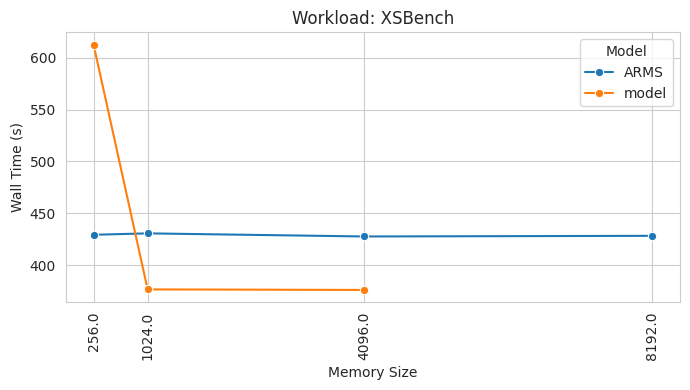

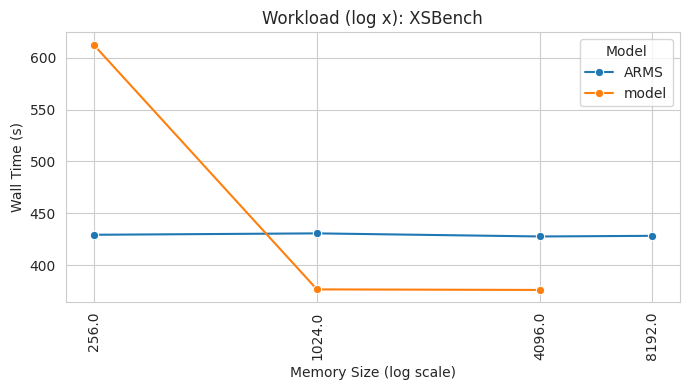

Percent differences (model vs ARMS) for workload: XSBench


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,429.301,612.765,42.735517
1,1024.0,430.656,376.614,-12.548763
2,4096.0,427.669,376.071,-12.064938
3,8192.0,428.287,NaN,NaN


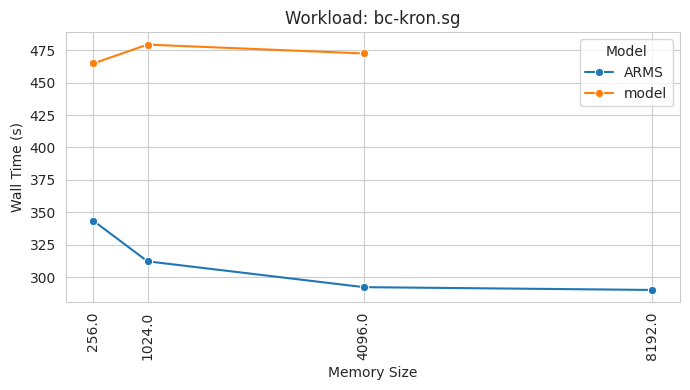

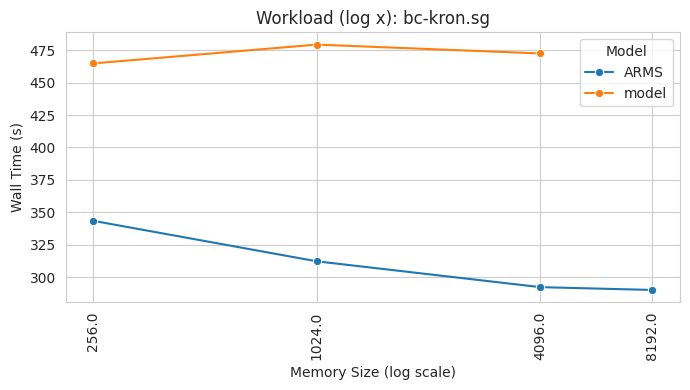

Percent differences (model vs ARMS) for workload: bc-kron.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,343.503,464.741,35.294597
1,1024.0,312.345,479.222,53.427140
2,4096.0,292.466,472.397,61.522023
3,8192.0,290.307,NaN,NaN


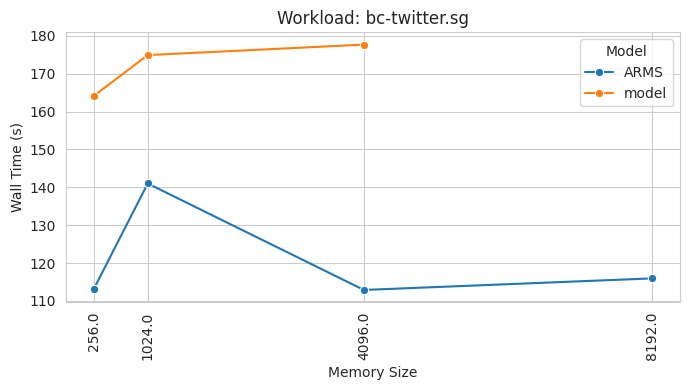

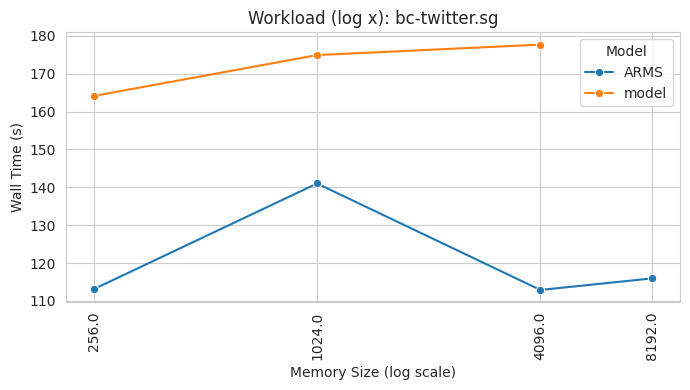

Percent differences (model vs ARMS) for workload: bc-twitter.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,113.119,164.096,45.064932
1,1024.0,141.009,174.890,24.027544
2,4096.0,112.914,177.658,57.339214
3,8192.0,115.964,NaN,NaN


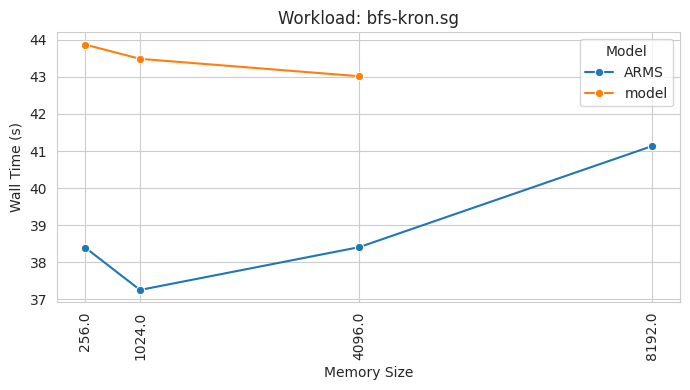

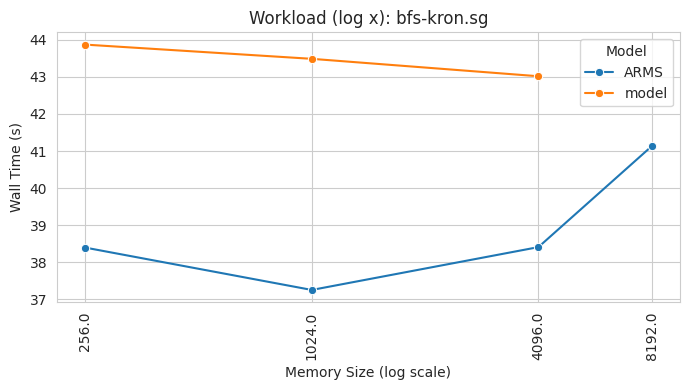

Percent differences (model vs ARMS) for workload: bfs-kron.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,38.394,43.872,14.267854
1,1024.0,37.251,43.488,16.743175
2,4096.0,38.407,43.018,12.005624
3,8192.0,41.129,NaN,NaN


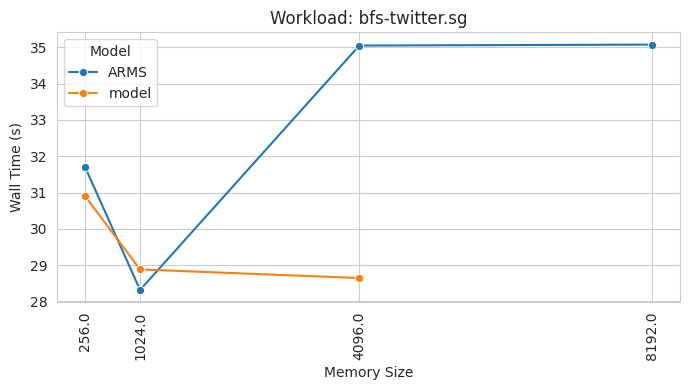

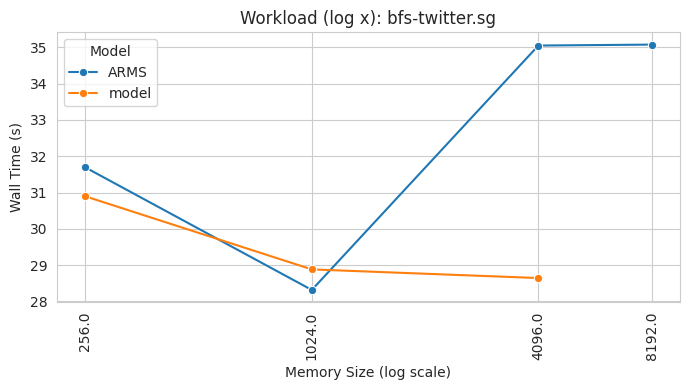

Percent differences (model vs ARMS) for workload: bfs-twitter.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,31.693,30.896,-2.514751
1,1024.0,28.316,28.882,1.998870
2,4096.0,35.049,28.644,-18.274416
3,8192.0,35.075,NaN,NaN


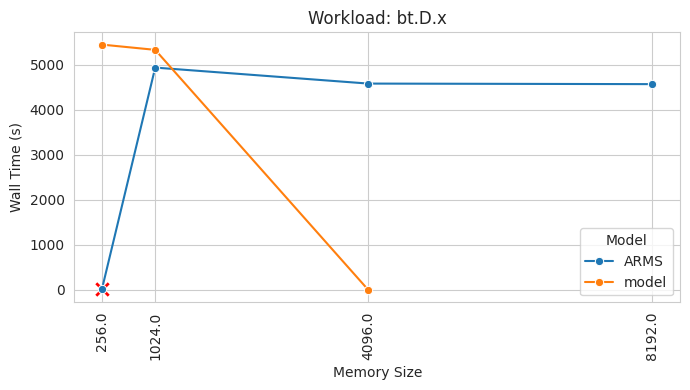

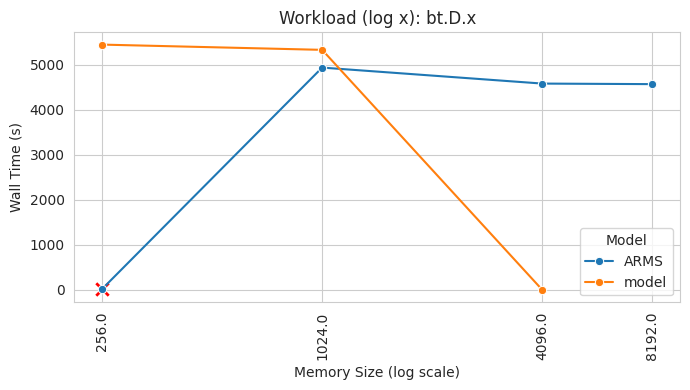

Percent differences (model vs ARMS) for workload: bt.D.x


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,17.284,5451.598,31441.298311
1,1024.0,4940.852,5334.809,7.973463
2,4096.0,4585.534,0.484,-99.989445
3,8192.0,4573.276,NaN,NaN


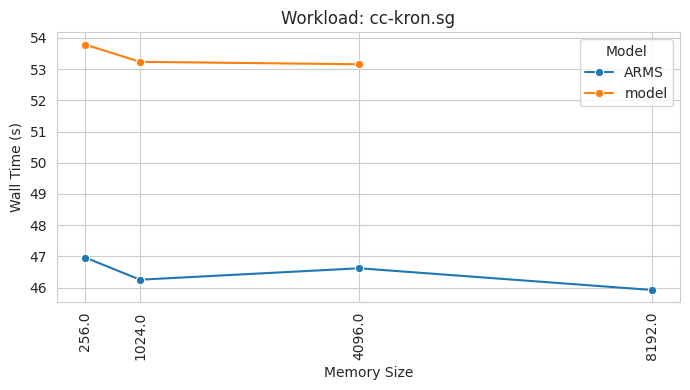

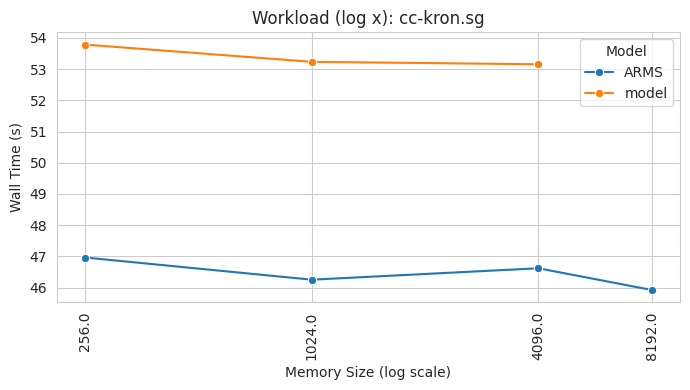

Percent differences (model vs ARMS) for workload: cc-kron.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,46.963,53.787,14.530588
1,1024.0,46.253,53.235,15.095237
2,4096.0,46.619,53.157,14.024325
3,8192.0,45.924,NaN,NaN


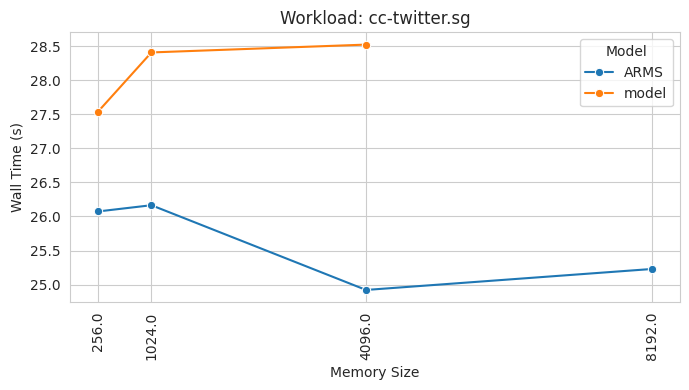

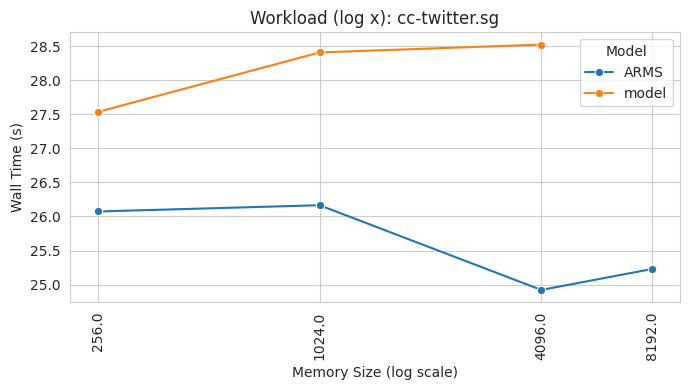

Percent differences (model vs ARMS) for workload: cc-twitter.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,26.073,27.533,5.599662
1,1024.0,26.165,28.406,8.564877
2,4096.0,24.922,28.521,14.441056
3,8192.0,25.230,NaN,NaN


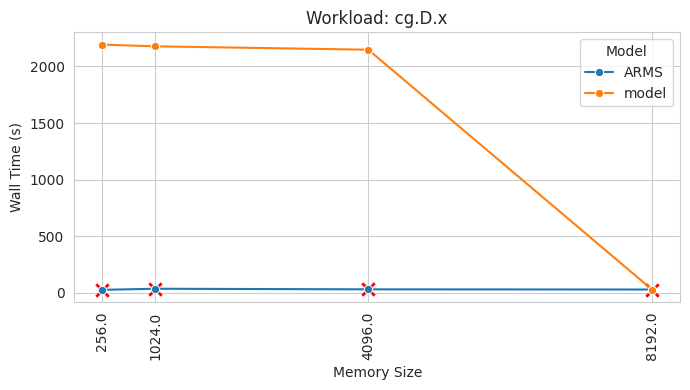

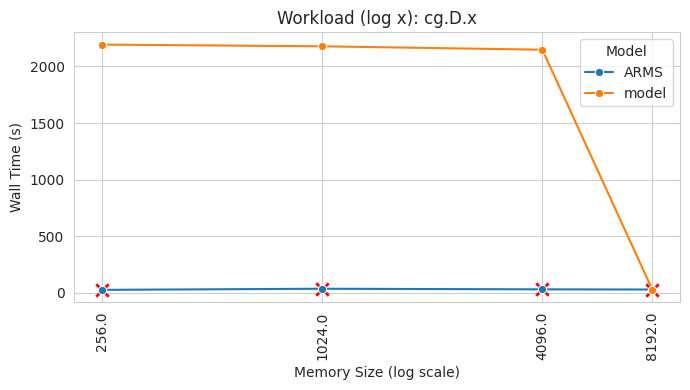

Percent differences (model vs ARMS) for workload: cg.D.x


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,26.501,2193.067,8175.412249
1,1024.0,36.226,2177.929,5912.060399
2,4096.0,30.934,2147.915,6843.541087
3,8192.0,29.297,25.532,-12.851145


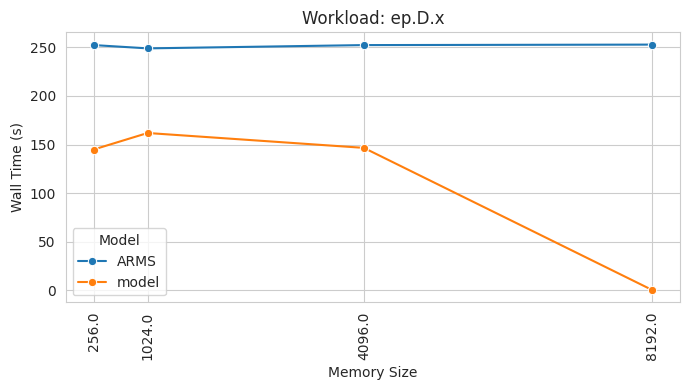

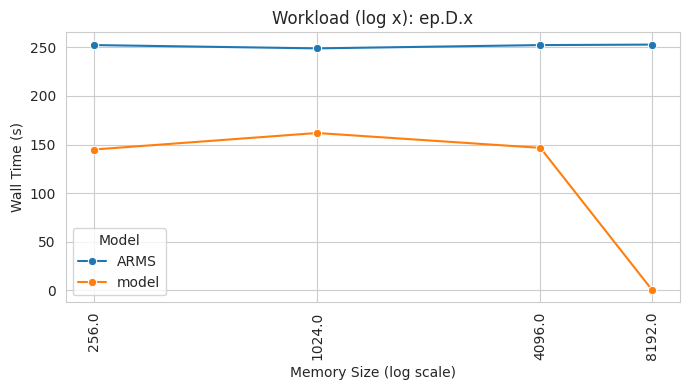

Percent differences (model vs ARMS) for workload: ep.D.x


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,252.219,144.822,-42.580852
1,1024.0,248.818,161.835,-34.958484
2,4096.0,252.197,146.551,-41.890268
3,8192.0,252.697,0.487,-99.807279


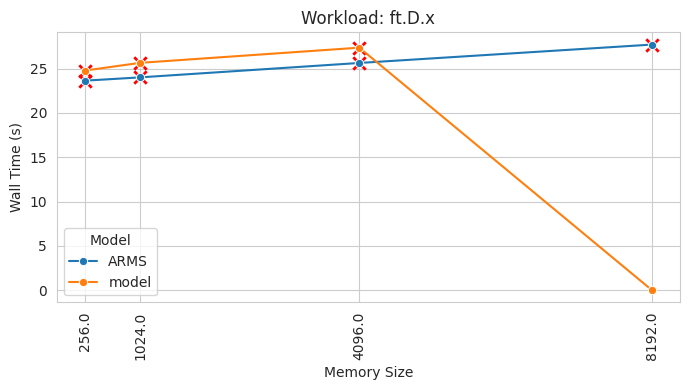

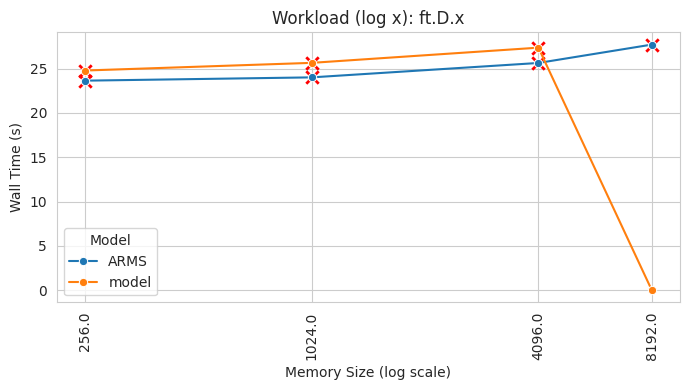

Percent differences (model vs ARMS) for workload: ft.D.x


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,23.642,24.786,4.838846
1,1024.0,24.013,25.651,6.821305
2,4096.0,25.638,27.365,6.736095
3,8192.0,27.710,0.028,-99.898953


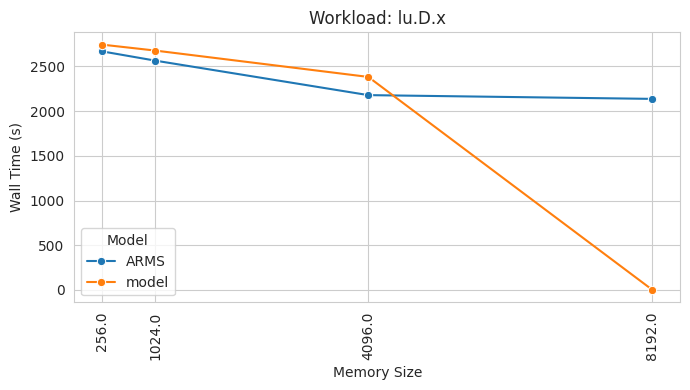

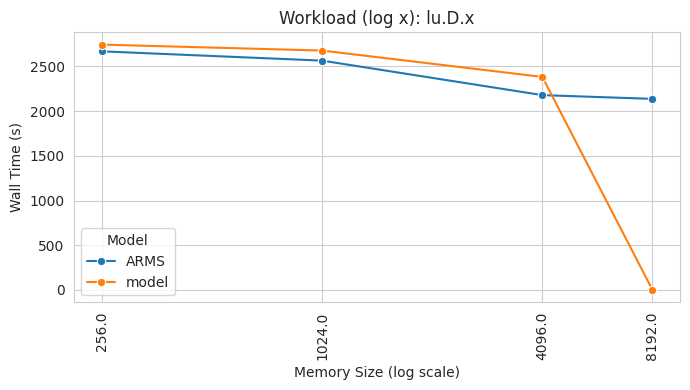

Percent differences (model vs ARMS) for workload: lu.D.x


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,2669.299,2744.704,2.824899
1,1024.0,2565.463,2678.015,4.387200
2,4096.0,2179.517,2383.064,9.339088
3,8192.0,2137.457,0.030,-99.998596


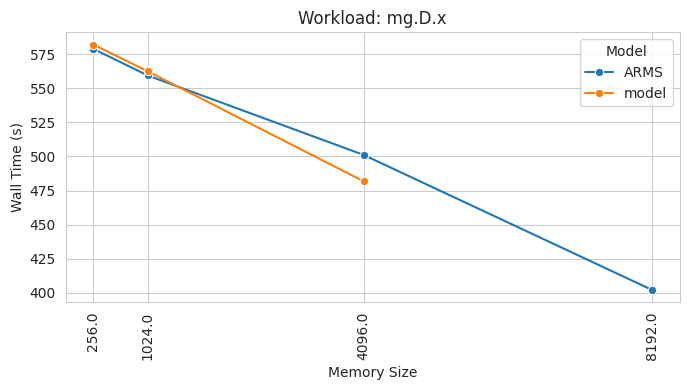

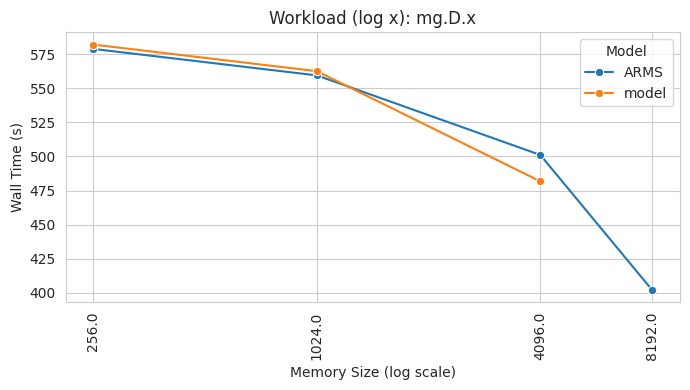

Percent differences (model vs ARMS) for workload: mg.D.x


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,578.965,582.140,0.548392
1,1024.0,559.534,562.612,0.550101
2,4096.0,501.120,481.705,-3.874322
3,8192.0,402.025,NaN,NaN


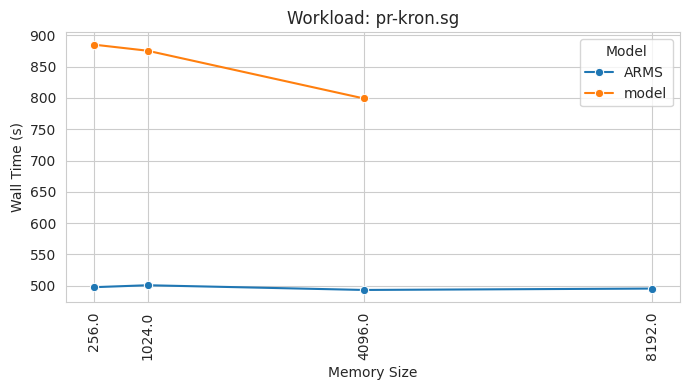

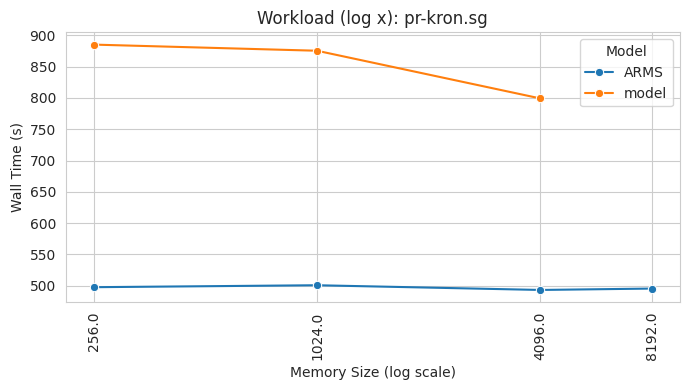

Percent differences (model vs ARMS) for workload: pr-kron.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,497.680,885.243,77.873935
1,1024.0,500.810,875.442,74.805216
2,4096.0,493.278,799.217,62.021619
3,8192.0,495.508,NaN,NaN


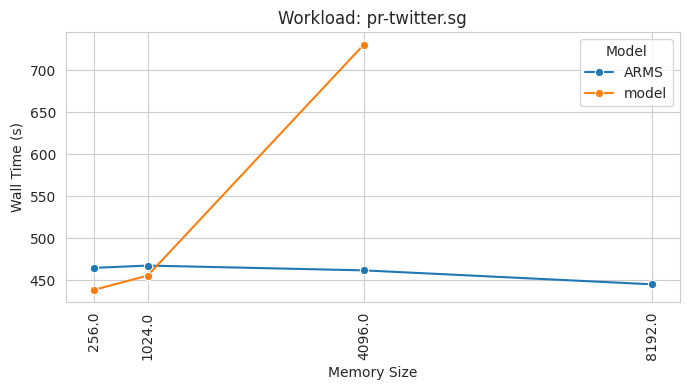

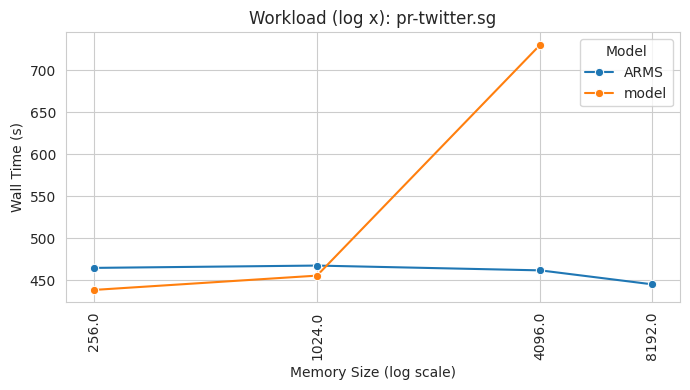

Percent differences (model vs ARMS) for workload: pr-twitter.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,464.582,438.326,-5.651532
1,1024.0,467.352,455.390,-2.559527
2,4096.0,461.642,730.397,58.217190
3,8192.0,445.039,NaN,NaN


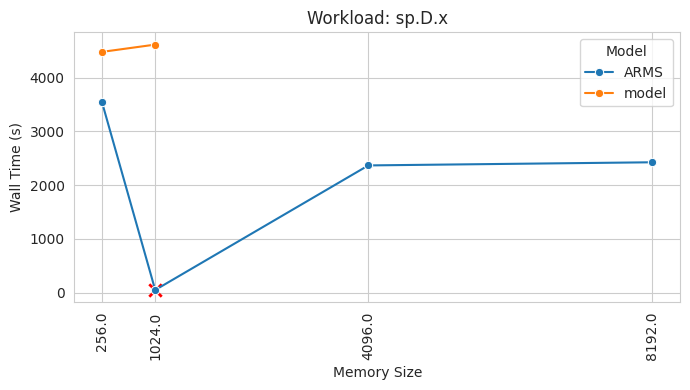

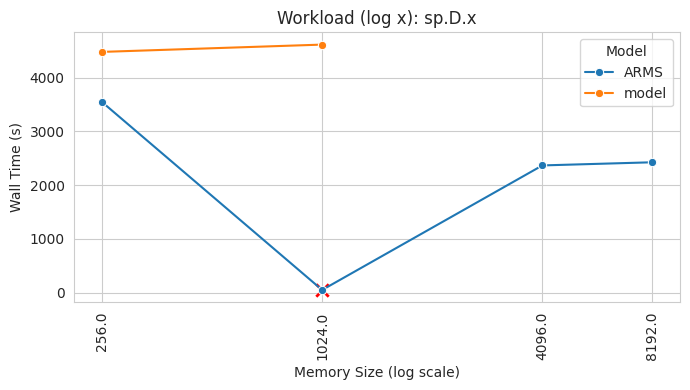

Percent differences (model vs ARMS) for workload: sp.D.x


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,3548.053,4479.344,26.247945
1,1024.0,49.856,4615.249,9157.158617
2,4096.0,2367.036,NaN,NaN
3,8192.0,2425.654,NaN,NaN


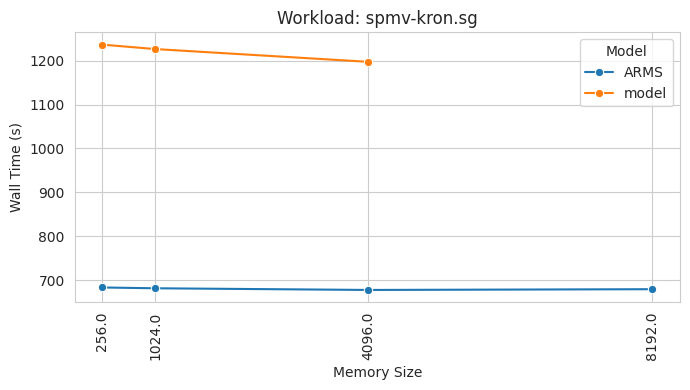

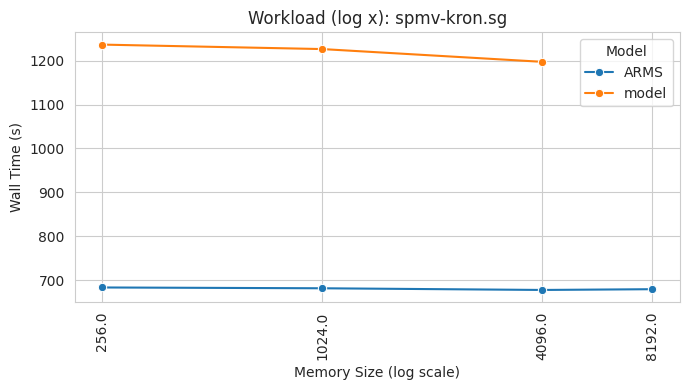

Percent differences (model vs ARMS) for workload: spmv-kron.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,683.472,1236.386,80.897828
1,1024.0,681.630,1226.213,79.894224
2,4096.0,677.814,1197.158,76.620430
3,8192.0,679.533,NaN,NaN


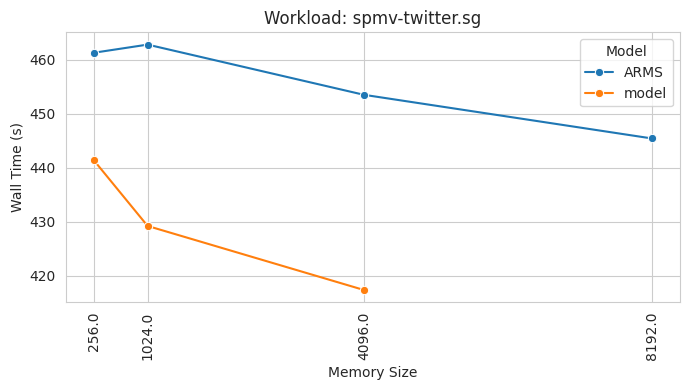

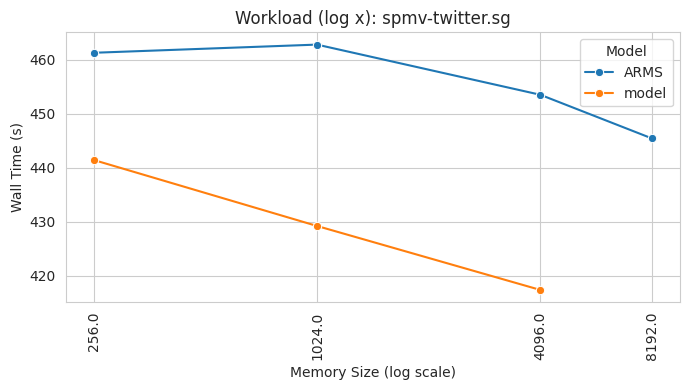

Percent differences (model vs ARMS) for workload: spmv-twitter.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,461.261,441.420,-4.301469
1,1024.0,462.777,429.196,-7.256411
2,4096.0,453.485,417.349,-7.968511
3,8192.0,445.395,NaN,NaN


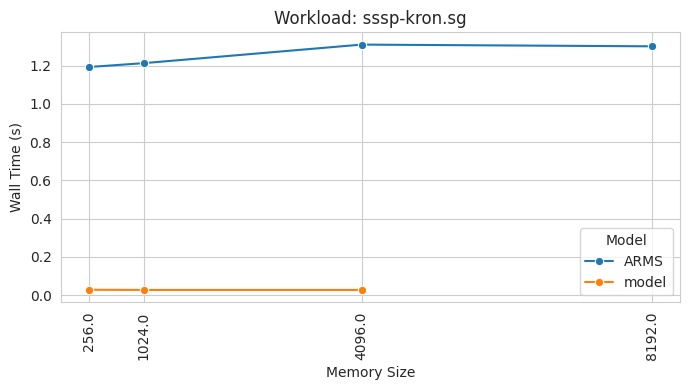

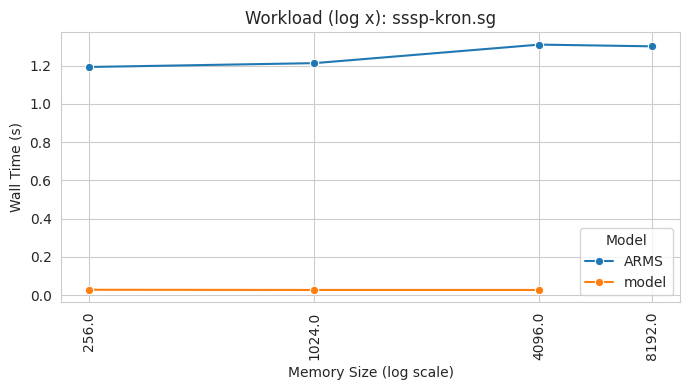

Percent differences (model vs ARMS) for workload: sssp-kron.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,1.193,0.028,-97.652976
1,1024.0,1.213,0.027,-97.774114
2,4096.0,1.310,0.027,-97.938931
3,8192.0,1.301,NaN,NaN


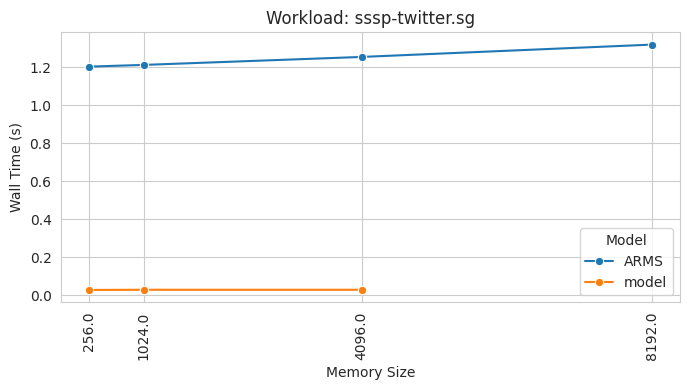

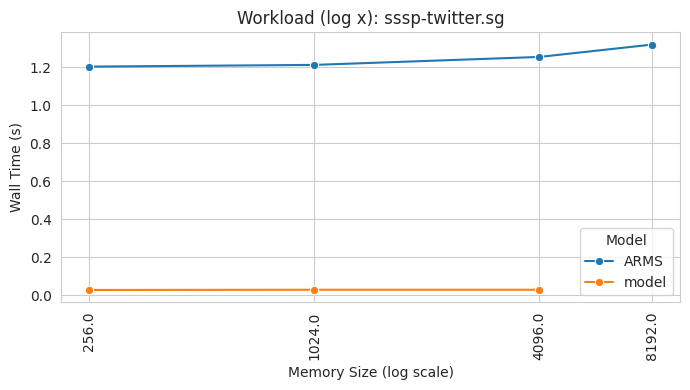

Percent differences (model vs ARMS) for workload: sssp-twitter.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,1.204,0.027,-97.757475
1,1024.0,1.213,0.028,-97.691674
2,4096.0,1.255,0.028,-97.768924
3,8192.0,1.320,NaN,NaN


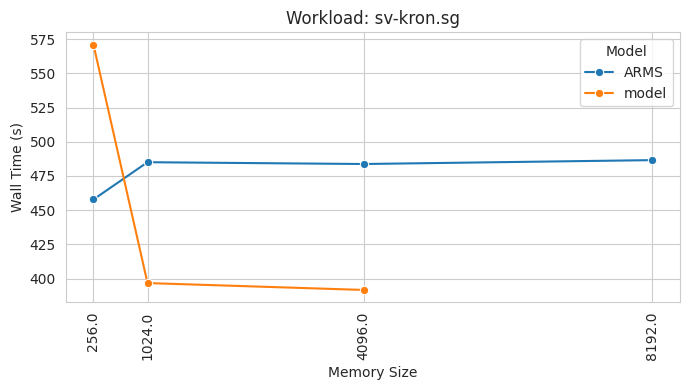

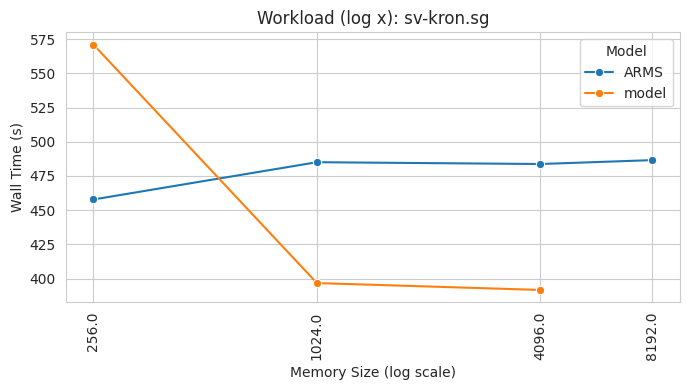

Percent differences (model vs ARMS) for workload: sv-kron.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,457.841,571.058,24.728454
1,1024.0,485.079,396.715,-18.216414
2,4096.0,483.760,391.682,-19.033818
3,8192.0,486.595,NaN,NaN


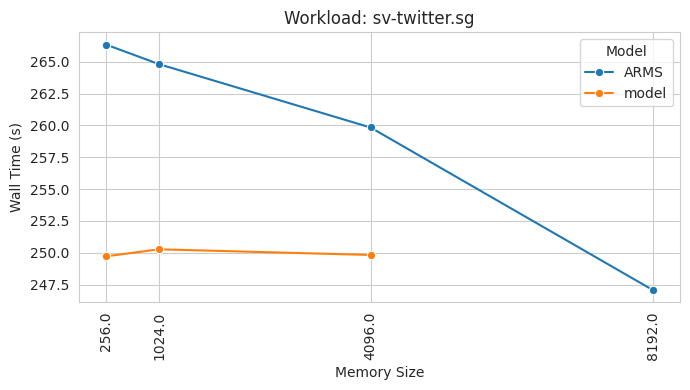

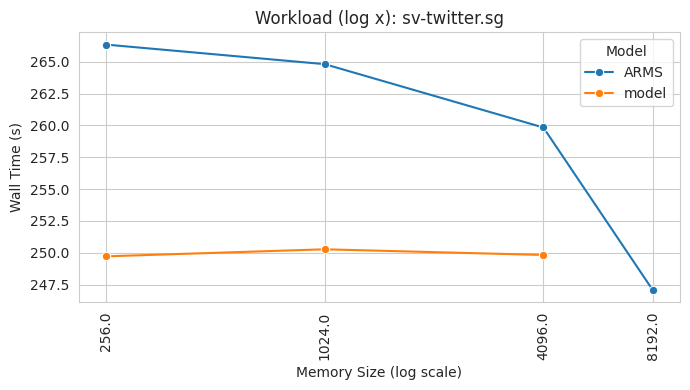

Percent differences (model vs ARMS) for workload: sv-twitter.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,266.354,249.723,-6.243946
1,1024.0,264.818,250.276,-5.491319
2,4096.0,259.843,249.831,-3.853096
3,8192.0,247.083,NaN,NaN


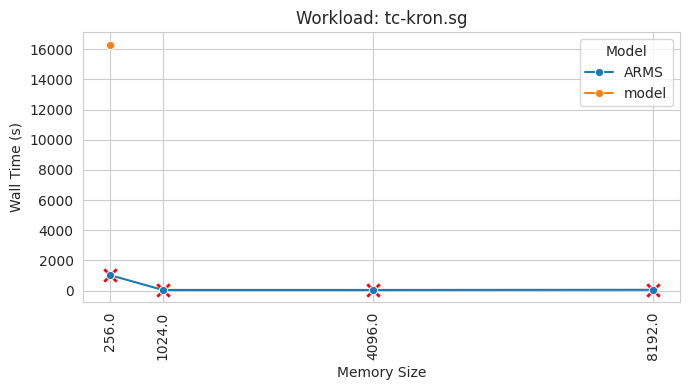

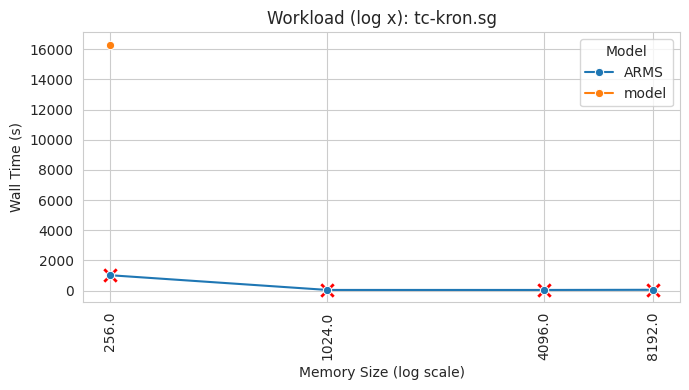

Percent differences (model vs ARMS) for workload: tc-kron.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,1019.769,16303.502,1498.744618
1,1024.0,45.626,NaN,NaN
2,4096.0,44.808,NaN,NaN
3,8192.0,55.057,NaN,NaN


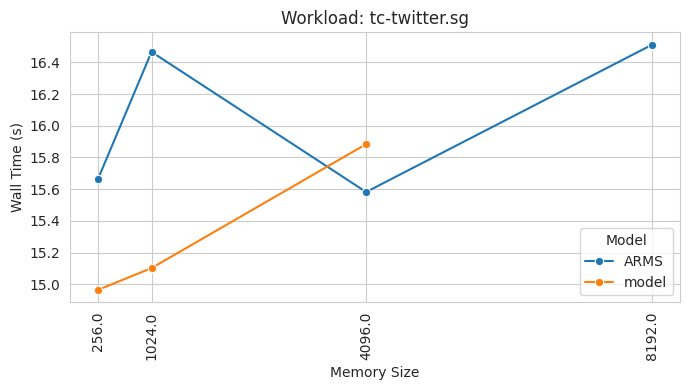

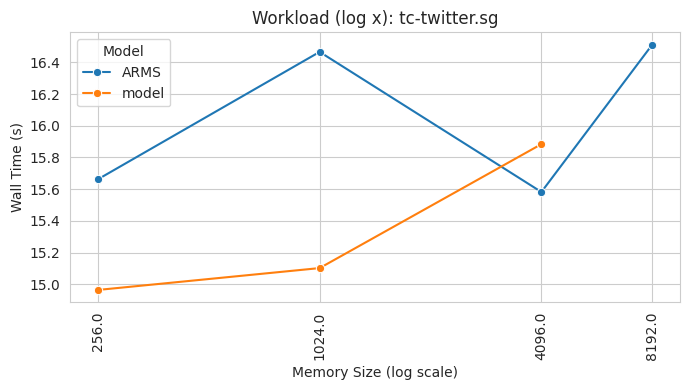

Percent differences (model vs ARMS) for workload: tc-twitter.sg


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,15.662,14.964,-4.456647
1,1024.0,16.466,15.102,-8.283736
2,4096.0,15.582,15.884,1.938134
3,8192.0,16.512,NaN,NaN


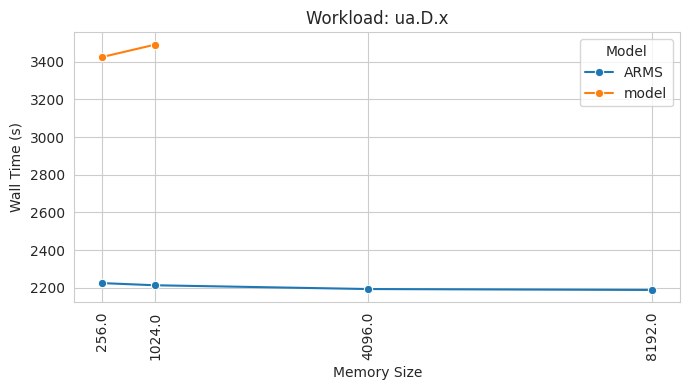

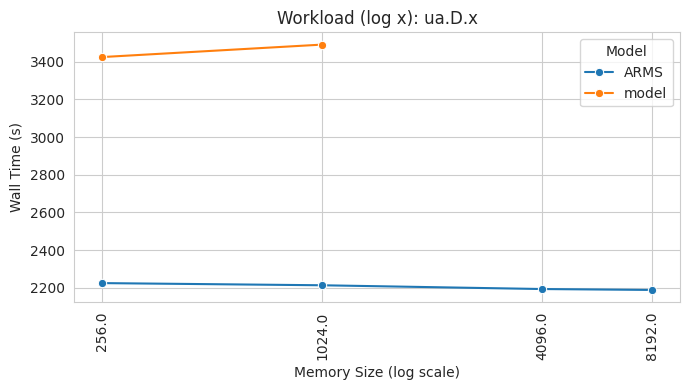

Percent differences (model vs ARMS) for workload: ua.D.x


model,size,ARMS,model,pct_diff_model_vs_ARMS
0,256.0,2225.298,3423.879,53.861595
1,1024.0,2213.780,3490.012,57.649450
2,4096.0,2193.779,NaN,NaN
3,8192.0,2188.941,NaN,NaN


Summary of percent differences across workloads:


model,size,ARMS,model,pct_diff_model_vs_ARMS,workload
0,256.0,429.301,612.765,42.735517,XSBench
1,1024.0,430.656,376.614,-12.548763,XSBench
2,4096.0,427.669,376.071,-12.064938,XSBench
3,8192.0,428.287,NaN,NaN,XSBench
4,256.0,343.503,464.741,35.294597,bc-kron.sg
...,...,...,...,...,...
95,8192.0,16.512,NaN,NaN,tc-twitter.sg
96,256.0,2225.298,3423.879,53.861595,ua.D.x
97,1024.0,2213.780,3490.012,57.649450,ua.D.x
98,4096.0,2193.779,NaN,NaN,ua.D.x


In [20]:
# Plot per-workload performance across sizes (linear + log) and show percent differences.
import matplotlib.pyplot as plt
import seaborn as sns
import math, re
from IPython.display import display

if 'final_df' not in globals():
    raise RuntimeError('final_df not found. Run previous cells first.')


plot_df = final_df.copy()
plot_df['size_bytes'] = plot_df['size']
plot_df = plot_df.dropna(subset=['workload', 'size_bytes'])

workloads = sorted(plot_df['workload'].unique())

sns.set_style('whitegrid')

percent_tables = {}

for wl in workloads:
    dfw = plot_df[plot_df['workload'] == wl].sort_values('size_bytes')
    if dfw.empty:
        continue
    # Percent difference table (model vs ARMS)
    pivot = dfw.pivot_table(index='size_bytes', columns='model', values='wall_time_seconds')
    if {'ARMS','model'}.issubset(pivot.columns):
        pivot['pct_diff_model_vs_ARMS'] = (pivot['model'] - pivot['ARMS']) / pivot['ARMS'] * 100.0
        pct_df = pivot.reset_index().rename(columns={'size_bytes':'size_bytes_raw'})
        pct_df['size'] = pct_df['size_bytes_raw']
        pct_df = pct_df[['size','ARMS','model','pct_diff_model_vs_ARMS']]
        percent_tables[wl] = pct_df
    else:
        percent_tables[wl] = None

    # Linear scale plot
    plt.figure(figsize=(7,4))
    ax = sns.lineplot(data=dfw, x='size_bytes', y='wall_time_seconds', hue='model', marker='o')
    err_rows = dfw[(dfw['error']) & dfw['wall_time_seconds'].notna()]
    if not err_rows.empty:
        for _, r in err_rows.iterrows():
            ax.scatter(r['size_bytes'], r['wall_time_seconds'], marker='x', s=80, color='red', linewidths=2)
    ticks = sorted(dfw['size_bytes'].unique())
    ax.set_xticks(ticks)
    ax.set_xticklabels([t for t in ticks])
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(90)
    ax.set_title(f'Workload: {wl}')
    ax.set_xlabel('Memory Size')
    ax.set_ylabel('Wall Time (s)')
    ax.legend(title='Model')
    plt.tight_layout()
    plt.show()

    # Log scale plot
    plt.figure(figsize=(7,4))
    ax = sns.lineplot(data=dfw, x='size_bytes', y='wall_time_seconds', hue='model', marker='o')
    err_rows = dfw[(dfw['error']) & dfw['wall_time_seconds'].notna()]
    if not err_rows.empty:
        for _, r in err_rows.iterrows():
            ax.scatter(r['size_bytes'], r['wall_time_seconds'], marker='x', s=80, color='red', linewidths=2)
    ticks = sorted(dfw['size_bytes'].unique())
    ax.set_xscale('log')
    ax.set_xticks(ticks)
    ax.set_xticklabels([t for t in ticks])
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(90)
    ax.set_title(f'Workload (log x): {wl}')
    ax.set_xlabel('Memory Size (log scale)')
    ax.set_ylabel('Wall Time (s)')
    ax.legend(title='Model')
    plt.tight_layout()
    plt.show()

    # Display percent differences table
    if percent_tables[wl] is not None:
        print(f"Percent differences (model vs ARMS) for workload: {wl}")
        display(percent_tables[wl])
    else:
        print(f"Percent differences unavailable (missing both models) for workload: {wl}")

# Collect all tables optionally into a single concatenated DataFrame
all_pct = []
for wl, tbl in percent_tables.items():
    if tbl is not None:
        t = tbl.copy()
        t['workload'] = wl
        all_pct.append(t)
if all_pct:
    percent_diff_df = pd.concat(all_pct, ignore_index=True)
    print('Summary of percent differences across workloads:')
    display(percent_diff_df)
